In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import arviz as az

c:\Program Files\Python313\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


We will use the Normal-Normal model to estimate the mean of a set of 50 test scores, which are known to follow a normal distribution with a variance of 10.

First, we will generate the test scores. The actual mean of the test scores will be 75.

In [22]:
np.random.seed(100)

# Known params
n = 50
sigma = 10
# Unknown params
mu = 75

# Generate a number of datapoints
y = np.random.normal(mu, sigma, n)


Now, we will estimate the posterior, which is the distribution of the mean of the dataset.

Our prior for the mean of the test scores will be a normal distribution with a mean of 80 and a variance of 5.

In [ ]:
# Hyperparams
mu_0 = 80
sigma_0 = 5

# Calculate posterior for Normal-Normal
y_mean = np.mean(y)
sigma2_n = 1 / (1/sigma_0**2 + n/sigma**2)
sigma_n = np.sqrt(sigma2_n)
mu_n = sigma2_n * (mu_0/sigma_0**2 + (n*y_mean)/sigma**2)

print("y_mean:", y_mean)
print("sigma2_n:", sigma2_n)
print("sigma_n:", sigma_n)
print("mu_n:", mu_n)

y_mean: 74.59199292126051
sigma2_n: 1.8518518518518516
sigma_n: 1.3608276348795434
mu_n: 74.99258603820418


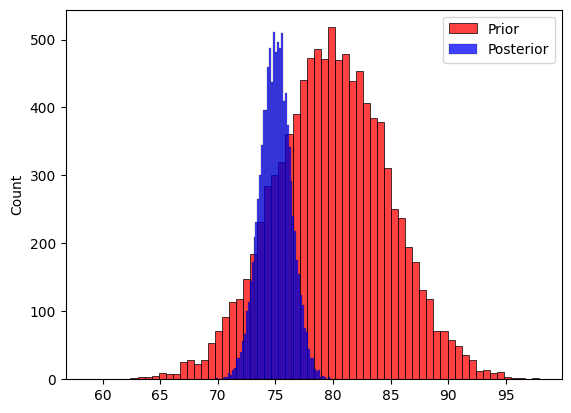

In [37]:
np.random.seed(200)

# Create plots of both distributions
n_points = 10000
prior_points = np.random.normal(mu_0, sigma_0, n_points)
posterior_points = np.random.normal(mu_n, sigma_n, n_points)

sns.histplot(prior_points, color="red", label='Prior')
sns.histplot(posterior_points, color="blue", label='Posterior')
plt.legend()

As we can see, the posterior indicates that the most likely test average is a 75, which is what was used to generate the test score data. And the variance is small, which indicates a higher confidence.